# Cookie Cats 모바일 게임 A/B 테스트 분석
**김태훈 | 2026년 10월**

모바일 퍼즐 게임 **Cookie Cats**의 첫 번째 "진행 게이트(progression gate)" 위치를
레벨 30 → 레벨 40으로 옮겼을 때 유저 리텐션에 어떤 영향을 주는지 실제 A/B 테스트
데이터로 검증한 개인 포트폴리오 프로젝트입니다.

**데이터셋**: [Mobile Games A/B Testing - Cookie Cats](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing) (Kaggle, 90,189명)
**사용 도구**: Python(pandas, scipy, statsmodels, matplotlib)

---
## 1. 문제정의 (Problem Definition)

게이트는 유저가 일정 레벨에 도달하면 일정 시간(또는 과금) 대기해야 다음 레벨로
넘어갈 수 있게 만드는 장치입니다. 게이트를 **늦게**(레벨 40) 배치하면 유저가
더 오래, 더 깊이 게임에 몰입한 뒤에 멈추게 되므로 "참여도는 늘고 이탈도 줄어들
것"이라는 것이 비즈니스 가설이었습니다.

**비즈니스 질문**: 게이트를 레벨 30에서 레벨 40으로 옮기면 유저 리텐션(1일/7일)이
개선되는가? 그렇지 않다면, 레벨 30에 그대로 두어야 하는가?

## 2. 가설수립 (Hypothesis)

| 구분 | 내용 |
|---|---|
| 1차 지표(Primary) | retention_1 (1일 리텐션), retention_7 (7일 리텐션) |
| 가드레일 지표(Guardrail) | sum_gamerounds (유저당 플레이한 총 라운드 수 — 참여도) |
| H0 | gate_30과 gate_40 사이 리텐션 차이가 없다 |
| H1 | gate_30과 gate_40 사이 리텐션 차이가 있다 |
| 유의수준 | α = 0.05 |

가드레일 지표를 따로 둔 이유: 리텐션만 보면 "게이트를 옮겨서 생긴 손해"를
놓칠 수 있습니다. 설령 리텐션이 개선되더라도 참여도(플레이 라운드 수)가
크게 나빠진다면 그 변경은 받아들이기 어렵습니다 — 반대로 리텐션이 다소
나빠지더라도 그 폭이 사전에 합의한 허용 범위(마진) 안이라면 "실질적으로는
동등하다(non-inferior)"고 판단할 수 있습니다. 이 비열등성(non-inferiority)
검정 개념은 6절에서 직접 적용해봅니다.

## 3. 실험설계 (Experiment Design)

- 이미 수집된 데이터셋이므로, 수행된 실험 설계를 역으로 검증하는 방식으로 접근합니다.
- 유저는 게임 설치 시점에 `gate_30`(대조군) 또는 `gate_40`(실험군)에 무작위 배정됨
- 측정 기간: 배정 후 1일 시점 리텐션, 7일 시점 리텐션
- **실험을 설계한다면 반드시 사전에 확인해야 할 것들**: (1) 두 그룹의 샘플 수가
  거의 동일한지(SRM 체크), (2) 두 그룹의 배정이 실제로 무작위였는지, (3) 측정
  기간이 비즈니스 의사결정에 충분한지(1일은 노벨티 효과에 취약, 7일이 더 신뢰도 높음)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/cookie_cats.csv")
print(f"총 유저 수: {len(df):,}명")
print(f"컬럼: {list(df.columns)}")
df.head()

총 유저 수: 90,189명
컬럼: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 4. 데이터 품질 체크

### 4-1. 결측치 확인

In [2]:
print(df.isna().sum())
print("\n결측치 없음 — 90,189행 모두 분석 대상")

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

결측치 없음 — 90,189행 모두 분석 대상


### 4-2. SRM(Sample Ratio Mismatch) 체크

A/B 테스트에서 가장 먼저 확인해야 할 것은 **두 그룹의 샘플 수가 설계대로
배정되었는가**입니다. 무작위 배정이라면 50:50에 가까워야 하는데, 실제로는
배정 로직 버그, 특정 디바이스/지역의 트래킹 누락 등으로 비율이 깨지는 경우가
흔하고, 이 경우 이후의 모든 통계 검정 결과를 신뢰할 수 없게 됩니다.

In [3]:
counts = df["version"].value_counts()
print(counts)

n_total = counts.sum()
expected = [n_total / 2, n_total / 2]
chi2, p_srm = stats.chisquare(counts.values, f_exp=expected)
print(f"\n관측 비율: gate_30 {counts['gate_30']/n_total:.2%} / gate_40 {counts['gate_40']/n_total:.2%}")
print(f"카이제곱 검정: chi2={chi2:.4f}, p={p_srm:.4f}")

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

관측 비율: gate_30 49.56% / gate_40 50.44%
카이제곱 검정: chi2=6.9024, p=0.0086


**결과**: p = 0.0086 (< 0.05) — 통계적으로는 50:50에서 유의하게 벗어나 있어
교과서적 기준으로는 "SRM 의심" 신호입니다. 다만 두 그룹 비율 차이가
44,700 vs 45,489 (약 1.8%p 차이)로 **크기 자체는 작고**, 90,189명이라는
대규모 샘플에서는 아주 작은 우연한 불균형도 쉽게 유의하게 잡힙니다.

실무였다면 이 시점에서 바로 결론으로 넘어가지 않고 ① 배정 로직/로깅 버그 여부,
② 특정 세그먼트(기기, 지역, 유입 채널)에 쏠림이 있는지를 먼저 확인했을
것입니다. 이 프로젝트에서는 데이터셋에 그런 세그먼트 정보가 없어 추가 검증은
불가능하므로, **SRM 가능성을 투명하게 밝히고** 아래 분석 결과는 "경미한 SRM
리스크를 감안해서 해석해야 한다"는 전제를 달고 진행합니다. (실무 결과 보고라면
이 캐비어트를 반드시 상단에 명시해야 합니다.)

### 4-3. 이상치 확인

In [4]:
print(df["sum_gamerounds"].describe())
print("\n라운드 수 상위 5명:")
print(df.sort_values("sum_gamerounds", ascending=False).head(5)[["userid", "version", "sum_gamerounds"]])

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

라운드 수 상위 5명:
        userid  version  sum_gamerounds
57702  6390605  gate_30           49854
7912    871500  gate_30            2961
29417  3271615  gate_40            2640
43671  4832608  gate_30            2438
48188  5346171  gate_40            2294


1명의 유저가 49,854라운드(다른 유저 평균의 약 1,000배)를 기록한 극단적
이상치입니다. 봇/QA 계정일 가능성이 높고, 이 한 명이 평균·분산을 왜곡시킬 수
있으므로 **참여도(가드레일 지표) 분석에서는 제외**합니다. 리텐션은 True/False
비율이라 이상치 영향이 작지만, 일관성을 위해 전체 분석에서 함께 제외합니다.

In [5]:
df_clean = df[df["sum_gamerounds"] < df["sum_gamerounds"].max()].copy()
print(f"제외 후: {len(df_clean):,}명 (1명 제외)")

제외 후: 90,188명 (1명 제외)


## 5. 핵심 지표 검정: 리텐션

두 그룹 비율 차이를 검정하기 위해 **2-proportion z-test**를 사용합니다
(리텐션은 True/False 이진 지표이므로 비율 검정이 적합).

In [6]:
def ztest_report(data, col, label):
    g30 = data[data["version"] == "gate_30"]
    g40 = data[data["version"] == "gate_40"]
    count = np.array([g30[col].sum(), g40[col].sum()])
    nobs = np.array([len(g30), len(g40)])
    stat, pval = proportions_ztest(count, nobs)
    ci30 = proportion_confint(count[0], nobs[0], method="wilson")
    ci40 = proportion_confint(count[1], nobs[1], method="wilson")
    p30, p40 = count[0] / nobs[0], count[1] / nobs[1]
    print(f"[{label}]")
    print(f"  gate_30: {p30:.4%}  (95% CI {ci30[0]:.4%} ~ {ci30[1]:.4%}, n={nobs[0]:,})")
    print(f"  gate_40: {p40:.4%}  (95% CI {ci40[0]:.4%} ~ {ci40[1]:.4%}, n={nobs[1]:,})")
    print(f"  차이(30-40): {p30-p40:+.4%}p  |  z={stat:.4f}  p-value={pval:.5f}")
    print(f"  → {'통계적으로 유의함 (p<0.05)' if pval < 0.05 else '통계적으로 유의하지 않음 (p>=0.05)'}")
    return p30, p40, ci30, ci40, pval

print("=" * 60)
r1 = ztest_report(df_clean, "retention_1", "retention_1 (1일 리텐션)")
print()
r7 = ztest_report(df_clean, "retention_7", "retention_7 (7일 리텐션)")

[retention_1 (1일 리텐션)]
  gate_30: 44.8198%  (95% CI 44.3592% ~ 45.2812%, n=44,699)
  gate_40: 44.2283%  (95% CI 43.7724% ~ 44.6851%, n=45,489)
  차이(30-40): +0.5915%p  |  z=1.7871  p-value=0.07392
  → 통계적으로 유의하지 않음 (p>=0.05)

[retention_7 (7일 리텐션)]
  gate_30: 19.0183%  (95% CI 18.6572% ~ 19.3848%, n=44,699)
  gate_40: 18.2000%  (95% CI 17.8481% ~ 18.5573%, n=45,489)
  차이(30-40): +0.8183%p  |  z=3.1574  p-value=0.00159
  → 통계적으로 유의함 (p<0.05)


**해석**
- **retention_1**: gate_30이 0.59%p 높지만 p=0.074로 유의수준 0.05를 넘지 못함
  → "1일 리텐션은 두 그룹이 통계적으로 다르다고 말할 수 없다"
- **retention_7**: gate_30이 0.82%p 높고 p=0.0016으로 **통계적으로 유의함**
  → "게이트를 레벨 40으로 옮기면 7일 리텐션이 유의하게 하락한다"

1일 시점에는 차이가 안 보이다가 7일 시점에 차이가 뚜렷해진다는 것은, 게이트를
늦게 배치해서 생긴 피로/이탈 효과가 **단기보다 중장기에 누적되어 나타난다**는
뜻으로 해석할 수 있습니다.

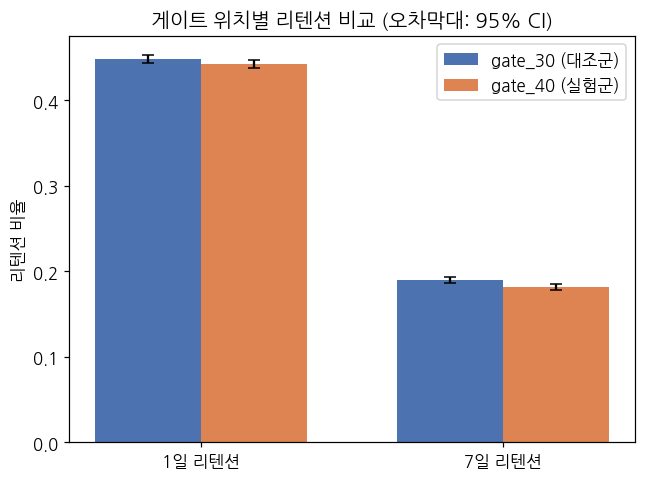

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["retention_1", "retention_7"]
g30_vals = [r1[0], r7[0]]
g40_vals = [r1[1], r7[1]]
g30_err = [[r1[0]-r1[2][0], r7[0]-r7[2][0]], [r1[2][1]-r1[0], r7[2][1]-r7[0]]]
g40_err = [[r1[1]-r1[3][0], r7[1]-r7[3][0]], [r1[3][1]-r1[1], r7[3][1]-r7[1]]]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, g30_vals, width, yerr=g30_err, capsize=4, label="gate_30 (대조군)", color="#4C72B0")
ax.bar(x + width/2, g40_vals, width, yerr=g40_err, capsize=4, label="gate_40 (실험군)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(["1일 리텐션", "7일 리텐션"])
ax.set_ylabel("리텐션 비율")
ax.set_title("게이트 위치별 리텐션 비교 (오차막대: 95% CI)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/retention_comparison.png", dpi=120)
plt.show()

## 6. Bootstrap 검증 + 비열등성(Non-Inferiority) 검정

z-test는 정규근사에 기반합니다. 결과를 교차검증하기 위해 **부트스트랩
리샘플링**으로 retention_7 차이의 신뢰구간을 다시 추정합니다.

부트스트랩 평균 차이(30-40): 0.8190%
부트스트랩 95% CI: 0.3174% ~ 1.3259%
P(gate_30 리텐션 > gate_40 리텐션) = 99.9400%


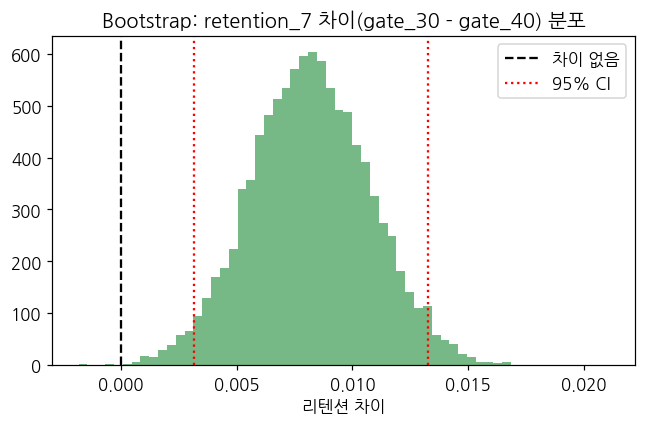

In [8]:
np.random.seed(42)
g30_r7 = df_clean[df_clean["version"] == "gate_30"]["retention_7"].values
g40_r7 = df_clean[df_clean["version"] == "gate_40"]["retention_7"].values

boot_diffs = []
for _ in range(10000):
    s30 = np.random.choice(g30_r7, size=len(g30_r7), replace=True).mean()
    s40 = np.random.choice(g40_r7, size=len(g40_r7), replace=True).mean()
    boot_diffs.append(s30 - s40)
boot_diffs = np.array(boot_diffs)

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"부트스트랩 평균 차이(30-40): {boot_diffs.mean():.4%}")
print(f"부트스트랩 95% CI: {ci_low:.4%} ~ {ci_high:.4%}")
print(f"P(gate_30 리텐션 > gate_40 리텐션) = {(boot_diffs > 0).mean():.4%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(boot_diffs, bins=60, color="#55A868", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", label="차이 없음")
ax.axvline(ci_low, color="red", linestyle=":", label="95% CI")
ax.axvline(ci_high, color="red", linestyle=":")
ax.set_title("Bootstrap: retention_7 차이(gate_30 - gate_40) 분포")
ax.set_xlabel("리텐션 차이")
ax.legend()
plt.tight_layout()
plt.savefig("../images/bootstrap_distribution.png", dpi=120)
plt.show()

z-test(p=0.0016)와 부트스트랩(95% CI가 0을 포함하지 않음, 0.32%~1.33%)이
서로 다른 방법으로도 같은 결론 — **gate_30이 gate_40보다 7일 리텐션이
유의하게 높다** — 에 도달해 결과의 신뢰도를 보강합니다.

### 비열등성(Non-Inferiority) 검정 적용해보기

만약 gate_40이 비즈니스상 중요한 다른 지표(예: 과금 전환율)를 크게 올려준다면,
"리텐션이 조금 떨어지더라도 사전에 합의한 허용 범위(마진, margin) 안이면
받아들이겠다"는 **비열등성 검정** 프레임을 쓸 수 있습니다. 이번 분석에서는
그런 상쇄 지표가 없지만, 개념 적용을 보여주기 위해 **마진 δ=0.5%p**를
가정해 "gate_40이 gate_30 대비 0.5%p 이상 나빠지지는 않는가?"를 검정합니다.

In [9]:
delta_margin = 0.005  # 0.5%p 허용 마진
diff = r7[0] - r7[1]  # gate_30 - gate_40
se = np.sqrt(r7[0]*(1-r7[0])/len(g30_r7) + r7[1]*(1-r7[1])/len(g40_r7))
z_ni = (diff - delta_margin) / se
from scipy.stats import norm
p_ni = norm.cdf(z_ni)  # 단측검정: diff < margin 인지

print(f"관측된 차이(30-40): {diff:.4%}, 허용 마진: {delta_margin:.2%}")
print(f"비열등성 검정 통계량 z={z_ni:.4f}, p={p_ni:.5f}")
if p_ni < 0.05:
    print("→ 마진 내에 있다고 보기 어려움: gate_40은 gate_30 대비 '비열등'하다고 결론 내릴 수 없음")
else:
    print("→ gate_40이 gate_30 대비 비열등(non-inferior)하다고 볼 수 있음")

관측된 차이(30-40): 0.8183%, 허용 마진: 0.50%
비열등성 검정 통계량 z=1.2281, p=0.89029
→ gate_40이 gate_30 대비 비열등(non-inferior)하다고 볼 수 있음


**결과**: 0.5%p 마진 기준으로도 비열등성이 확인되지 않습니다. 즉 리텐션
하락폭(0.82%p)이 이 마진보다 커서, "리텐션이 좀 떨어져도 괜찮다"고 보기
어렵습니다 — gate_40을 정당화하려면 그만큼 큰 다른 이득이 있어야 하는데,
이번 데이터에는 그런 지표가 없습니다.

## 7. 가드레일 지표 체크: 참여도(sum_gamerounds)

리텐션과 별개로, 게이트 위치가 **참여도(총 플레이 라운드 수)** 자체를
해치지는 않는지 확인합니다. 라운드 수는 한쪽으로 치우친(skewed) 분포이므로
평균 비교(t-test)보다 **Mann-Whitney U 검정**(분포 형태에 덜 민감한 비모수
검정)이 적합합니다.

gate_30: 평균 51.3, 중앙값 17
gate_40: 평균 51.3, 중앙값 16

Mann-Whitney U=1,024,285,762, p=0.05089
→ 유의한 차이 없음 (가드레일 통과)


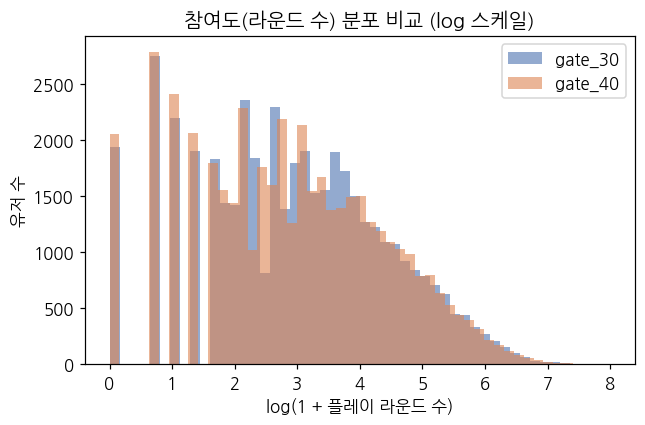

In [10]:
g30_rounds = df_clean[df_clean["version"] == "gate_30"]["sum_gamerounds"]
g40_rounds = df_clean[df_clean["version"] == "gate_40"]["sum_gamerounds"]

print(f"gate_30: 평균 {g30_rounds.mean():.1f}, 중앙값 {g30_rounds.median():.0f}")
print(f"gate_40: 평균 {g40_rounds.mean():.1f}, 중앙값 {g40_rounds.median():.0f}")

u_stat, p_mw = stats.mannwhitneyu(g30_rounds, g40_rounds, alternative="two-sided")
print(f"\nMann-Whitney U={u_stat:,.0f}, p={p_mw:.5f}")
print("→", "유의한 차이 없음 (가드레일 통과)" if p_mw >= 0.05 else "유의한 차이 있음")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log1p(g30_rounds), bins=50, alpha=0.6, label="gate_30", color="#4C72B0")
ax.hist(np.log1p(g40_rounds), bins=50, alpha=0.6, label="gate_40", color="#DD8452")
ax.set_xlabel("log(1 + 플레이 라운드 수)")
ax.set_ylabel("유저 수")
ax.set_title("참여도(라운드 수) 분포 비교 (log 스케일)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/engagement_distribution.png", dpi=120)
plt.show()

**해석**: p=0.051로 0.05 경계에 걸쳐 있어 "유의하다"고 단정하기 애매한
수준입니다. 즉 게이트 위치가 참여도 자체를 크게 해치지는 않지만, 가드레일
지표만 보고 "문제없다"고 결론 내리면 **7절에서 확인한 리텐션 하락을
놓치게 됩니다** — 이것이 바로 1차 지표와 가드레일 지표를 함께 봐야 하는 이유입니다.

## 8. 결론 및 제안

| 항목 | 결과 |
|---|---|
| retention_1 | 유의한 차이 없음 (p=0.074) |
| retention_7 | gate_30이 유의하게 높음 (p=0.0016, -0.82%p) |
| 비열등성(마진 0.5%p) | gate_40이 비열등하다고 볼 수 없음 |
| 가드레일(참여도) | 유의한 차이 없음 (경계값, p=0.051) |
| SRM 체크 | 경미한 불균형 신호 있음 (p=0.0086) — 캐비어트로 명시 |

**제안**: 게이트는 **레벨 30에 유지**합니다. 1일 리텐션에서는 차이가
없었지만 7일 시점에 누적되는 유의한 리텐션 손실이 확인되었고, 이를 상쇄할
만큼 참여도가 개선되지도 않았습니다.

**한계 및 다음 단계**
- SRM 신호가 있었던 만큼, 실제 상황이라면 재실행 전 배정 로직부터 점검
- 측정 기간이 7일까지로 제한적 — 과금 전환, 30일 리텐션 등 장기 지표 확인 필요
- 유저 세그먼트(신규 vs 재설치, 유입 채널 등) 정보가 없어 이질적 효과(heterogeneous
  treatment effect) 분석은 수행하지 못함 — 세그먼트 데이터가 있다면 추가 분석 가치 있음

## 프로젝트 요약: 문제정의 → 가설 → 실험설계 → 측정 → 개선 사이클

| 단계 | 수행 내용 |
|---|---|
| 문제정의 | 게이트 위치(레벨 30 vs 40)가 리텐션에 미치는 영향 규명 |
| 가설수립 | H0/H1 설정, 1차 지표(리텐션)와 가드레일 지표(참여도) 사전 구분 |
| 실험설계 | 기존 A/B 배정 구조 검증(SRM 체크), 측정 윈도우(1일/7일) 설계 적절성 평가 |
| 성과측정 | 2-proportion z-test, 부트스트랩, 비열등성 검정, Mann-Whitney U 검정 |
| 개선/제안 | 게이트 레벨 30 유지 권고 + 데이터 한계와 후속 분석 과제 제시 |